# Group Members - Group No.28

<table border="1" cellpadding="5" cellspacing="0" style="border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th>Full Name</th>
      <th>Registration Number</th>
      <th>Degree Programme</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>AMON TOROTO</td>
      <td>T24-03-10331</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>CHANILA JOSEPH</td>
      <td>T24-03-26045</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>GALANDA SWEYA</td>
      <td>T24-03-10322</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>RAYMOND MAKUKA</td>
      <td>T24-03-14523</td>
      <td>BSc-CS2</td>
    </tr>
    <tr>
      <td>MUKSINI BUSHIRI</td>
      <td>T24-03-14126</td>
      <td>BSc-CS2</td>
    </tr>
  </tbody>
</table>


# GROUP ASSIGNMENT
Abalone Snail, Machine Learning Case Study
![Abalone Snail Image Sample](./snail.png)

[GitHub Repository Link](https://github.com/Gsweya/CLASS_CODES/tree/second_yr/sem_two/second_year_code/semester_two/CG%20222%20-%20DATA%20SCIENCE/CLASS_ASSIGNMNENT)

## Importing the Required Libraries

In [16]:
#importing data libraries

# libraries for statistics and data reading 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)


## Load the Dataset

In [17]:
df = pd.read_csv("./abalone.data.csv")

# Creating the age column
df["Age"] = df["Rings"] + 1.5

In [18]:
df["Volume"] = df["Length"] * df["Diameter"] * df["Height"]
df["Density"] = df["Whole weight"] / df["Volume"].replace(0, np.nan)
df["Shucked_ratio"] = df["Shucked weight"] / df["Whole weight"]
df["Shell_ratio"] = df["Shell weight"] / df["Whole weight"]
df["Viscera_ratio"] = df["Viscera weight"] / df["Whole weight"]

## Data Preview Of the Data

In [19]:
df.sample(10)

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age,Volume,Density,Shucked_ratio,Shell_ratio,Viscera_ratio
2167,F,0.370,0.275,0.085,0.2405,0.1040,0.0535,0.0700,5,6.5,0.008649,27.807487,0.432432,0.291060,0.222453
2755,F,0.525,0.415,0.150,0.7055,0.3290,0.1470,0.1990,10,11.5,0.032681,21.587302,0.466336,0.282069,0.208363
1327,M,0.565,0.390,0.125,0.7440,0.3520,0.1300,0.1685,11,12.5,0.027544,27.011572,0.473118,0.226478,0.174731
2251,M,0.600,0.485,0.175,1.2675,0.4995,0.2815,0.3800,13,14.5,0.050925,24.889543,0.394083,0.299803,0.222091
2746,I,0.485,0.365,0.140,0.4475,0.1895,0.0925,0.2305,8,9.5,0.024783,18.056368,0.423464,0.515084,0.206704
3292,F,0.495,0.375,0.150,0.5970,0.2615,0.1350,0.1780,11,12.5,0.027844,21.441077,0.438023,0.298157,0.226131
288,M,0.440,0.355,0.125,0.4775,0.1320,0.0815,0.1900,9,10.5,0.019525,24.455826,0.276440,0.397906,0.170681
3162,M,0.640,0.490,0.140,1.1940,0.4445,0.2380,0.3750,15,16.5,0.043904,27.195700,0.372278,0.314070,0.199330
1763,M,0.775,0.630,0.250,2.7795,1.3485,0.7600,0.5780,12,13.5,0.122063,22.771121,0.485159,0.207951,0.273430
2768,I,0.560,0.435,0.135,0.7200,0.3290,0.1030,0.2510,11,12.5,0.032886,21.893815,0.456944,0.348611,0.143056


## Dataset Strucuture

In [20]:
print(f"There are {df.shape}, rows and columns respectfully")

There are (4177, 15), rows and columns respectfully


### Listed Columns inside the data collected

In [21]:
df.columns

Index(['gender', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings', 'Age',
       'Volume', 'Density', 'Shucked_ratio', 'Shell_ratio', 'Viscera_ratio'],
      dtype='object')

### Nature of the Data Collected (Data Types)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
 9   Age             4177 non-null   float64
 10  Volume          4177 non-null   float64
 11  Density         4175 non-null   float64
 12  Shucked_ratio   4177 non-null   float64
 13  Shell_ratio     4177 non-null   float64
 14  Viscera_ratio   4177 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 489.6+ KB


### Checking for missing Values 

In [23]:
df.isnull().sum()


gender            0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
Age               0
Volume            0
Density           2
Shucked_ratio     0
Shell_ratio       0
Viscera_ratio     0
dtype: int64

### Statistical Overview of the Data

In [24]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age,Volume,Density,Shucked_ratio,Shell_ratio,Viscera_ratio
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4175.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684,11.433684,0.034715,24.589943,0.432414,0.295605,0.218537
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169,3.224169,0.021153,5.220748,0.105765,0.058785,0.034361
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000,2.500000,0.000000,3.254380,0.175258,0.109341,0.007634
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000,9.500000,0.017911,22.224486,0.395100,0.266097,0.198586
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000,10.500000,0.032809,24.082668,0.430592,0.290870,0.217252
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000,12.500000,0.048739,26.226240,0.466175,0.319410,0.236945
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000,30.500000,0.205137,245.287521,4.691943,2.615672,0.665399


### Feature Engineering

## Finding Correlation

In [25]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age,Volume,Density,Shucked_ratio,Shell_ratio,Viscera_ratio
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720,0.556720,0.917937,-0.182636,0.030147,-0.197950,-0.024799
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660,0.574660,0.923353,-0.193071,0.018539,-0.179516,-0.033789
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467,0.557467,0.905318,-0.319823,-0.021986,-0.133190,-0.016512
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390,0.540390,0.959871,-0.062418,0.019431,-0.213362,-0.030692
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884,0.420884,0.922982,-0.040021,0.163885,-0.293407,-0.049985
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819,0.503819,0.933789,-0.069274,0.005403,-0.235023,0.169291
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574,0.627574,0.938357,-0.118026,-0.059150,-0.006170,-0.067558
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,1.000000,0.544952,-0.146446,-0.211494,0.120111,-0.066942
Age,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,1.000000,0.544952,-0.146446,-0.211494,0.120111,-0.066942
Volume,0.917937,0.923353,0.905318,0.959871,0.922982,0.933789,0.938357,0.544952,0.544952,1.000000,-0.226954,0.004279,-0.159552,-0.013359


### Correlation with the Target (Age)

In [26]:
correlation_matrix["Age"].sort_values(ascending=False)

Age               1.000000
Rings             1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Volume            0.544952
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Shell_ratio       0.120111
Viscera_ratio    -0.066942
Density          -0.146446
Shucked_ratio    -0.211494
Name: Age, dtype: float64

### Correlation with Rings 

In [27]:
correlation_matrix["Rings"].sort_values(ascending=False)

Age               1.000000
Rings             1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Volume            0.544952
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Shell_ratio       0.120111
Viscera_ratio    -0.066942
Density          -0.146446
Shucked_ratio    -0.211494
Name: Rings, dtype: float64

### Correlation Heatmap

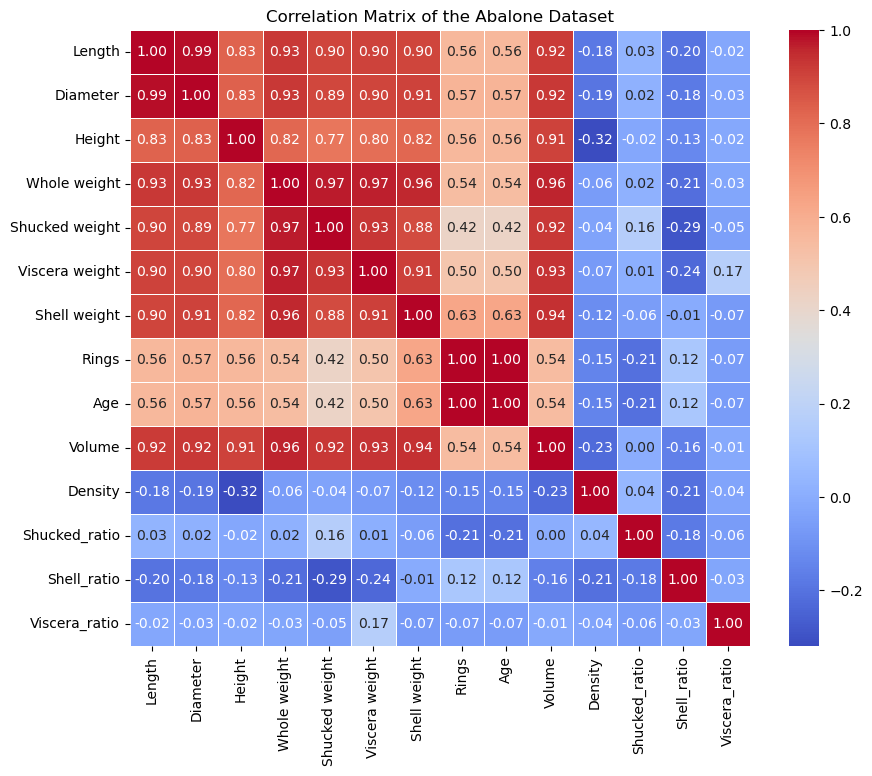

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of the Abalone Dataset")
plt.show()

### FInding the Outliers

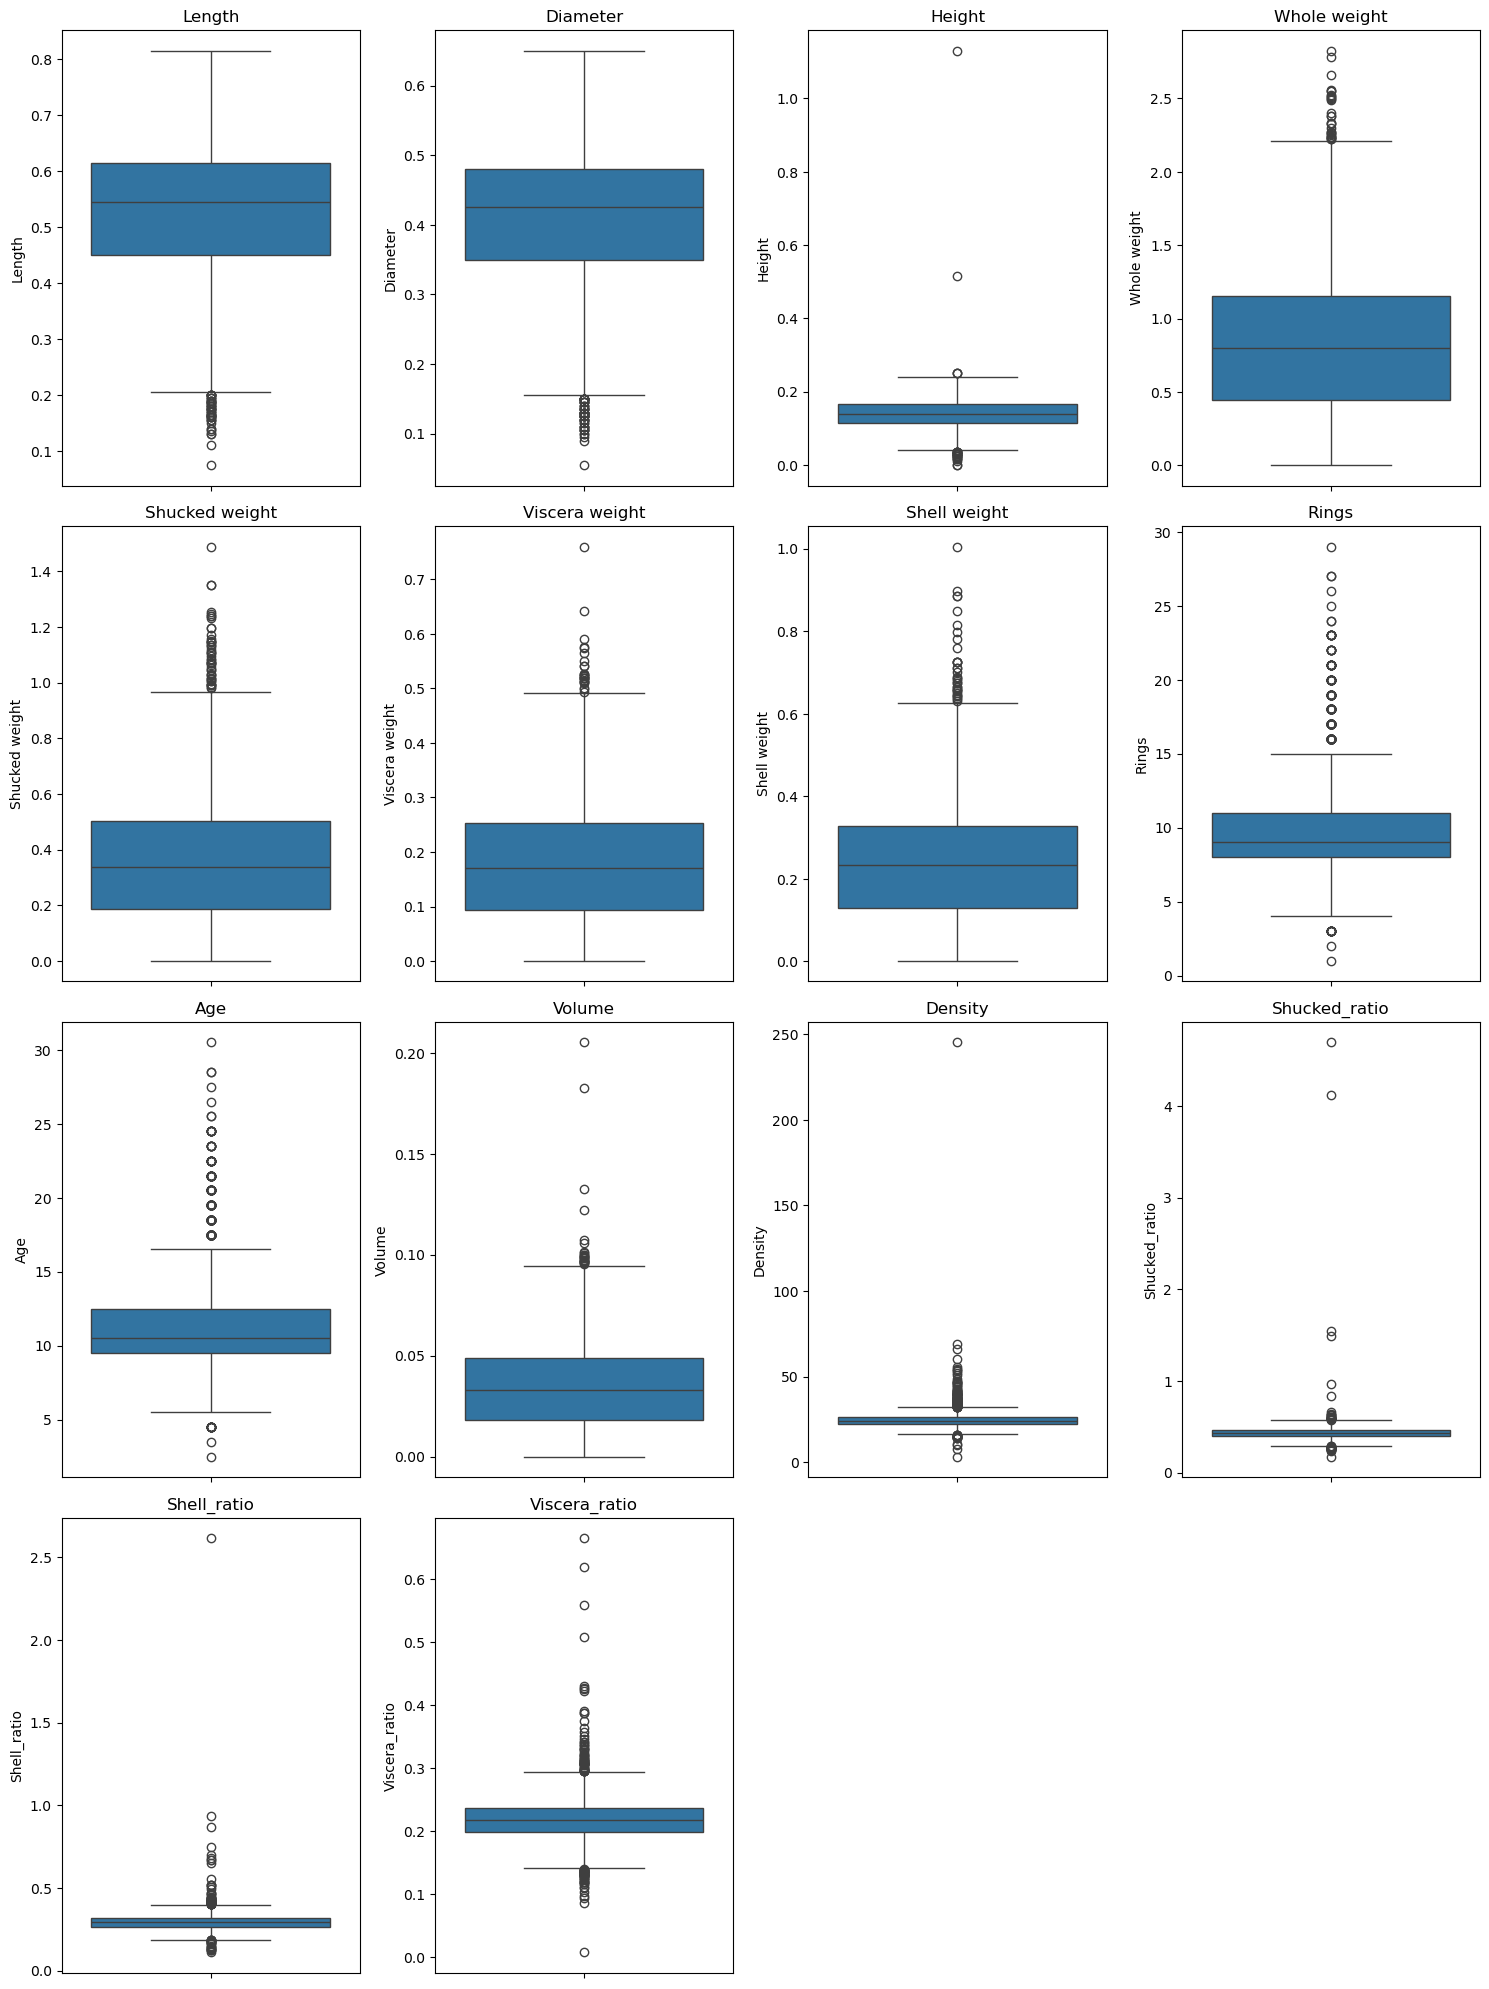

In [29]:
import math
numeric_columns = df.select_dtypes(include="number").columns
n_cols = len(numeric_columns)
cols = 4
rows = math.ceil(n_cols / cols)

plt.figure(figsize=(15, 5 * rows))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()


### Data Cleaning and Removing the Outliers using IQR Method 
Where For below is Q1 - 1.5 x IQR 
For Above 
Q3 + 1.5 x IQR

In [30]:
# Cell 30 — only filter on feature columns, not Age/Rings
feature_cols = df.drop(columns=["Age", "Rings"]).select_dtypes(include="number").columns

Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    ~((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]


### Comparing the Data Original and The New Data

In [31]:
print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", df_clean.shape)

Original Dataset Shape : (4177, 15)
Cleaned Dataset Shape  : (3723, 15)


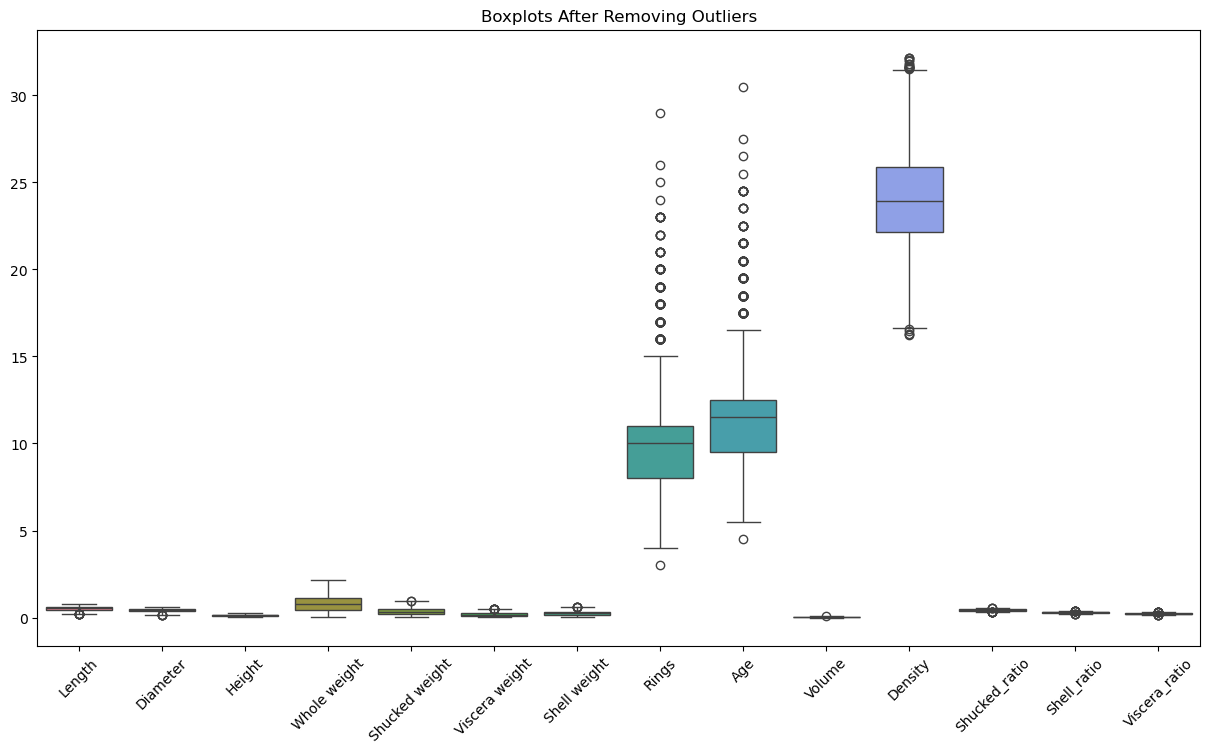

In [32]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df_clean.select_dtypes(include="number"))

plt.title("Boxplots After Removing Outliers")

plt.xticks(rotation=45)

plt.show()

In [33]:
correlation_matrix = df_clean.corr(numeric_only=True)
correlation_matrix["Rings"].sort_values(ascending=False)

Age               1.000000
Rings             1.000000
Shell weight      0.600631
Height            0.583528
Diameter          0.534772
Volume            0.532098
Whole weight      0.517922
Length            0.513704
Viscera weight    0.485544
Shucked weight    0.405456
Shell_ratio       0.215494
Viscera_ratio    -0.023753
Density          -0.172815
Shucked_ratio    -0.367672
Name: Rings, dtype: float64

### Old vs New Correlation Matrices

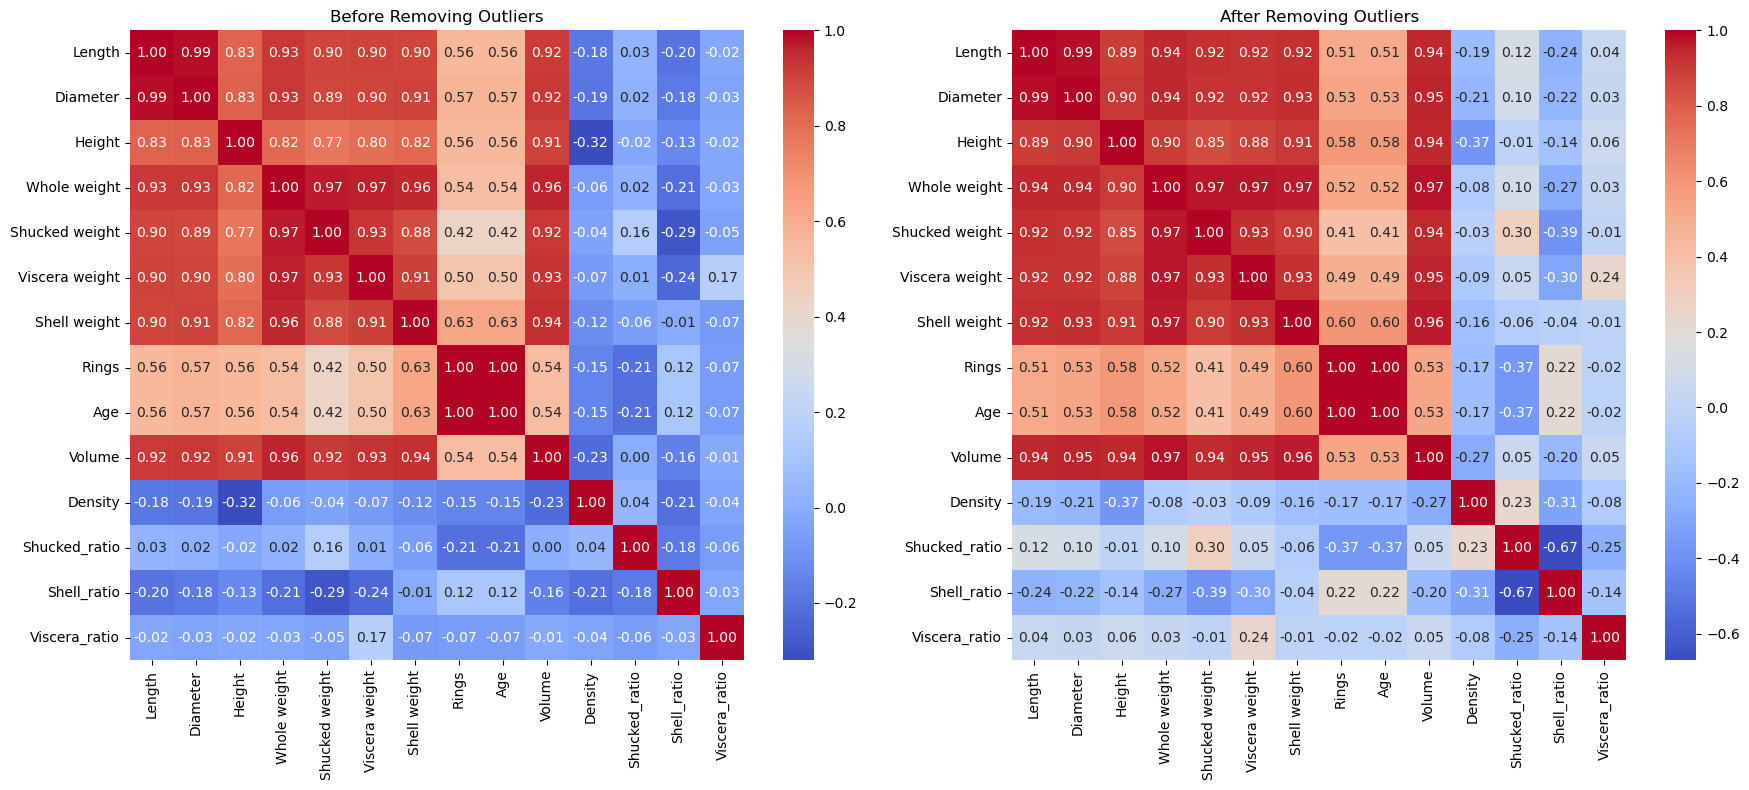

In [34]:
# Correlation matrices
corr_before = df.corr(numeric_only=True)
corr_after = df_clean.corr(numeric_only=True)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before removing outliers
sns.heatmap(
    corr_before,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)

axes[0].set_title("Before Removing Outliers")

# After removing outliers
sns.heatmap(
    corr_after,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1]
)

axes[1].set_title("After Removing Outliers")

plt.tight_layout()
plt.show()

# Feature Selection

In [35]:
# Features (Predictors)
X = df_clean.drop(columns=["Age", "Rings"])

# Target
y = df_clean["Age"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['gender', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Shucked weight', 'Viscera weight', 'Shell weight', 'Volume', 'Density',
       'Shucked_ratio', 'Shell_ratio', 'Viscera_ratio'],
      dtype='object')

Target:
Age


In [36]:
X.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Volume,Density,Shucked_ratio,Shell_ratio,Viscera_ratio
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,0.008347,27.014076,0.441242,0.310421,0.215078
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,0.030051,22.528368,0.378877,0.310192,0.209010
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,0.020075,25.703611,0.417636,0.300388,0.220930
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,0.006732,30.451575,0.436585,0.268293,0.192683
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,0.012113,29.019608,0.401138,0.341394,0.220484


In [37]:
y.head()

1     8.5
2    10.5
3    11.5
4     8.5
5     9.5
Name: Age, dtype: float64

### Data Preprocessing (For non-numericals: Gender)

In [38]:
categorical_features = ["gender"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="passthrough"
)

### Split the Dataset

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (2978, 13)
Testing set : (745, 13)


### Verify the Data Split

In [40]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (2978, 13)
Testing Features : (745, 13)
Training Target  : (2978,)
Testing Target   : (745,)


# Model Training

In [41]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

trained_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)

    print(f"{name} trained successfully.")

# Tune Random Forest separately
param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5]
}

rf_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=42))])

search = RandomizedSearchCV(rf_pipeline, param_dist, n_iter=20, cv=5, scoring="r2", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_rf = search.best_estimator_
print(search.best_params_, search.best_score_)

trained_models["Random Forest"] = best_rf
predictions["Random Forest"] = best_rf.predict(X_test)
print("Random Forest tuned and trained successfully.")


Linear Regression trained successfully.
Decision Tree trained successfully.


Gradient Boosting trained successfully.


/home/sweya/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/sweya/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/sweya/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81

{'model__n_estimators': 200, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 12} 0.5413257530340555
Random Forest tuned and trained successfully.


# Model Evaluation

In [42]:
results = []

for name, y_pred in predictions.items():

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Round values for neat presentation
results_df = results_df.round(4)

# Sorting the Best Model
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,R² Score,MAE,MSE,RMSE,MAPE (%)
3,Random Forest,0.5403,1.4838,4.5969,2.1440,12.2884
0,Linear Regression,0.5341,1.5326,4.6584,2.1583,12.7289
2,Gradient Boosting,0.5269,1.4898,4.7312,2.1751,12.3093
1,Decision Tree,0.4636,1.6181,5.3636,2.3160,13.4174


# Feature Importance

In [43]:
rf_model = trained_models["Random Forest"].named_steps["model"]

encoded_features = trained_models["Random Forest"]\
    .named_steps["preprocessor"]\
    .get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,remainder__Shell weight,0.278869
11,remainder__Shucked_ratio,0.225001
4,remainder__Height,0.112105
9,remainder__Volume,0.092882
12,remainder__Shell_ratio,0.067034
7,remainder__Viscera weight,0.050969
13,remainder__Viscera_ratio,0.040576
5,remainder__Whole weight,0.034844
6,remainder__Shucked weight,0.022527
10,remainder__Density,0.020939


## Plotting Feature Importance

/tmp/ipykernel_148358/1954146019.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


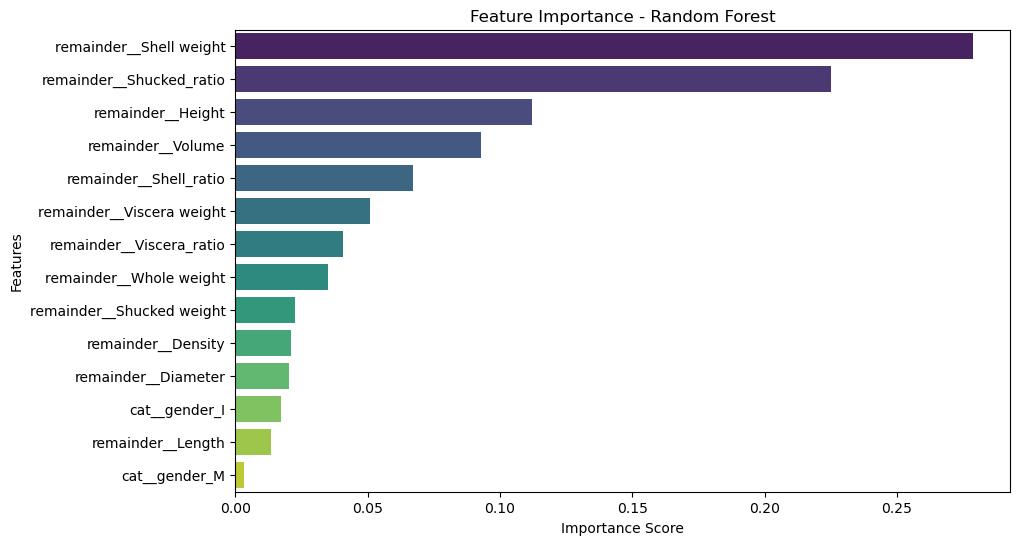

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Saving the Model

In [45]:
import joblib

# Save the best model (Random Forest)
joblib.dump(
    trained_models["Random Forest"],
    "abalone_age_predictor.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Load Model and Test

In [49]:
loaded_model = joblib.load("abalone_age_predictor.pkl")

new_data = pd.DataFrame({
    "gender": ["M"],
    "Length": [0.55],
    "Diameter": [0.44],
    "Height": [0.15],
    "Whole weight": [0.90],
    "Shucked weight": [0.42],
    "Viscera weight": [0.18],
    "Shell weight": [0.25]
})

# Compute engineered features
new_data["Volume"] = new_data["Length"] * new_data["Diameter"] * new_data["Height"]
new_data["Density"] = new_data["Whole weight"] / new_data["Volume"].replace(0, np.nan)
new_data["Shucked_ratio"] = new_data["Shucked weight"] / new_data["Whole weight"]
new_data["Shell_ratio"] = new_data["Shell weight"] / new_data["Whole weight"]
new_data["Viscera_ratio"] = new_data["Viscera weight"] / new_data["Whole weight"]

predicted_age = loaded_model.predict(new_data)

print(f"Predicted Age: {predicted_age[0]:.2f} years")


Predicted Age: 10.54 years


# Flexible Model Trier

In [ ]:
gender = input("Gender (M/F/I): ")

length = float(input("Length: "))
diameter = float(input("Diameter: "))
height = float(input("Height: "))
whole_weight = float(input("Whole Weight: "))
shucked_weight = float(input("Shucked Weight: "))
viscera_weight = float(input("Viscera Weight: "))
shell_weight = float(input("Shell Weight: "))

new_data = pd.DataFrame({
    "gender": [gender],
    "Length": [length],
    "Diameter": [diameter],
    "Height": [height],
    "Whole weight": [whole_weight],
    "Shucked weight": [shucked_weight],
    "Viscera weight": [viscera_weight],
    "Shell weight": [shell_weight]
})

# Compute engineered features
new_data["Volume"] = new_data["Length"] * new_data["Diameter"] * new_data["Height"]
new_data["Density"] = new_data["Whole weight"] / new_data["Volume"].replace(0, np.nan)
new_data["Shucked_ratio"] = new_data["Shucked weight"] / new_data["Whole weight"]
new_data["Shell_ratio"] = new_data["Shell weight"] / new_data["Whole weight"]
new_data["Viscera_ratio"] = new_data["Viscera weight"] / new_data["Whole weight"]

predicted_age = loaded_model.predict(new_data)

print(f"\nPredicted Age: {predicted_age[0]:.2f} years")
